---
# **Laboratory 7 - Exercises**

---
## Exercise 1

<img src='https://drive.google.com/uc?id=1C2vyT2X19C_IekWf3rELuF4SumvJxo2b'>

1. Write a Python script that computes P(g|do(r)) seen during the lecture

2. What is the causal effect of the cloudy weather $c$ on the grass' wetness $g$? (i.e. math expression of $P(g | do(c))$)

3. Between rain and sprinkler, which one has the stronger causal effect on the wetness, $P(g | do(r))$ or $P(g | do(s))$ ?

4. Compute the average causal effect (ACE) of the sprinkler on the wetness $g$.

In [ ]:
!pip install pyagrum

In [ ]:
#from IPython.display import display, Math, Latex
from IPython.display import display
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.causal as csl
import pyagrum.causal.notebook as cslnb

In [ ]:
# bayesian model construction
m1 = gum.fastBN("Cloudy{Y|N}->Rain{Y|N}->GrassWet{Y|N}<-Sprinkler{Y|N}<-Cloudy")

m1.cpt("Cloudy")[:] = [0.5,0.5]

m1.cpt("Sprinkler")[{'Cloudy':'Y'}] = [0.1,0.9]
m1.cpt("Sprinkler")[{'Cloudy':'N'}] = [0.5,0.5]

m1.cpt("Rain")[{'Cloudy':'Y'}] = [0.8,0.2]
m1.cpt("Rain")[{'Cloudy':'N'}] = [0.1,0.9]

m1.cpt("GrassWet")[{'Sprinkler':'Y','Rain':'Y'}]=[0.95,0.05]
m1.cpt("GrassWet")[{'Sprinkler':'Y','Rain':'N'}]=[0.9,0.1]
m1.cpt("GrassWet")[{'Sprinkler':'N','Rain':'Y'}]=[0.9,0.1]
m1.cpt("GrassWet")[{'Sprinkler':'N','Rain':'N'}]=[0.1,0.9]

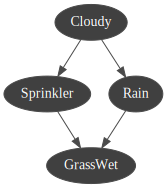

In [ ]:
#test bayesian model
gnb.showBN(m1)
gnb.flow.row(m1.cpt("Cloudy"),m1.cpt("Rain"),m1.cpt("Sprinkler"),m1.cpt("GrassWet"))

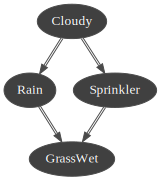

In [ ]:
# create causal model
d1 = csl.CausalModel(m1)
cslnb.showCausalModel(d1)

In [ ]:
# P(g|r)
P_G_given_R_direct = gum.getPosterior(m1, target='GrassWet', evs={'Rain':'Y'})
display(P_G_given_R_direct)

(pyagrum.Tensor@0x4eb3070) 
  GrassWet         |
Y        |N        |
---------|---------|
 0.9072  | 0.0928  |

To calculate the causal effect without showing the graph, you can directly use the `causalEffect` method from your causal model `d1`.

In [ ]:
# P(g|do(r)
causal_effect_g_do_r = csl.causalImpact(d1, 'GrassWet', doing='Rain', values={'Rain':0})
display(causal_effect_g_do_r[1])

(pyagrum.Tensor@0x88e0200) 
  GrassWet         |
Y        |N        |
---------|---------|
 0.9150  | 0.0850  |

In [ ]:
# P(g|do(s)
causal_effect_g_do_r = csl.causalImpact(d1, 'GrassWet', doing='Sprinkler', values={'Sprinkler':0})
display(causal_effect_g_do_r[1])

(pyagrum.Tensor@0x8634890) 
  GrassWet         |
Y        |N        |
---------|---------|
 0.9225  | 0.0775  |

In [ ]:
# ACE P(g|do(s)) - P(g|do(¬s))
causal_effect_g_do_r = csl.causalImpact(d1, 'GrassWet', doing='Sprinkler')
display(causal_effect_g_do_r[1])
display("ACE: " + str(causal_effect_g_do_r[1][0,0]) + " - " + str(causal_effect_g_do_r[1][1,0]) + " = " + str(causal_effect_g_do_r[1][0,0]-causal_effect_g_do_r[1][1,0]))

(pyagrum.Tensor@0x8d049e0) 
      ||  GrassWet         |
Sprink||Y        |N        |
------||---------|---------|
Y     || 0.9225  | 0.0775  |
N     || 0.4600  | 0.5400  |

'ACE: 0.9225 - 0.46 = 0.46249999999999997'